Dídac Costa Gargallo - u252353

Senyals i Sistemes I

3/12

**Lab 6: IIR Filtering**


The objective for this lab is to help you understand the relationship between the location
of poles and zeros in the z-domain, the impulse response h[n] in the n-domain, and the frequency
response $H(e^{j\omega})$. We use the system function,
represented as a ratio of polynomials in $z^{-1}$, which can be expressed in either factored or expanded form as:

$$
H(z) = G\frac{\prod_{k=1}^M (1-z_kz^{-1}) }{\prod_{k=1}^N (1-p_kz^{-1})} = \frac{ \sum_{k=0}^M b_kz^{-k}}{ 1- \sum_{k=1}^N a_kz^{-k} }
$$

In [142]:
import numpy as np
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_frequency_response

**1. IIR filters to extract the envelope**

In the previous labs, you extracted the envelope from your reference signal by applying the following system:

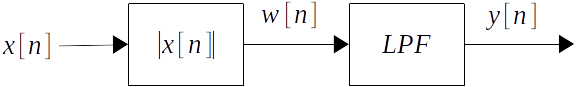

where $w[n] = |x[n]|$ and $y[n]$ was the output of a low-pass FIR filter (averaging filter). In this exercise, you will re-implement this low-pass filter as an IIR.

1.1 First, copy the functions envelope and synthesize from previous work and obtain the same synthesis. 



In [143]:
# Definim un altre cop les funcions synthesize i envelope
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y


def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    
    # Rectificació de valor absolut (full-wave rectifier)
    x_rectified = np.abs(x)

    # Coeficients del filtre de mitjana
    b = np.ones(N) / N

    # Aplicació del filtre FIR amb mode 'same'
    y = np.convolve(x_rectified, b, mode='same')

    return y

# Carreguem el senyal de referència
reference, fs = load_audio('audio/reference.wav')

# Paràmetres del senyal sintetitzat
f0 = 915.16                     # freqüència fonamental
phi = -np.pi / 2                # fase inicial
A_ref = 0.13                    # amplitud de referència
duration = len(reference) / fs # duració basada en el senyal de referència
t = np.linspace(0, duration, len(reference))  # vector de temps

# Amplituds relatives mesurades (fins al 7è harmònic)
Ak = [1, 0.6, 0.06, 0.03, 0.03, 0.007, 0.003]

# Generem el senyal sintetitzat
synth = synthesize(f0, phi, Ak, t)

# Calculem l’envolvent del senyal de referència
N_env = 40
env = envelope(reference, N_env)

# Apliquem l’envolvent al senyal sintetitzat
synth *= env

# Normalització del senyal
synth = A_ref * synth / np.max(np.abs(synth))

1.2 Let's take a look at the following system:

$$
H(z) = G\frac{1+z^{-1}}{1-rz^{-1}} \quad   0<r<1 \quad, G = \frac{1-r}{2}
$$

Note that the coefficients of the filter are the following:

$$
b_0 = 1, \quad b_1 = 1, \quad a_0 = 1, \quad a_1 = -r, \quad
$$

i. Find the zeros and poles of the system analytically.

El zero es troba quan z+1=0, és a dir, quan z=-1.

El pol es troba quan z-r=0, és a dir, quan z=r.

Com r només pot tenir valors entre 0 i 1, sense incloure els dos límits, G, és a dir, (1-r)/2, no pot donar ni 0 ni infinit.

ii. Use the function `np.roots` to find the zeros and poles using Python. Compare the results with part i.

In [144]:
# Agafem una r vàlida qualsevol
r = np.round(np.random.rand(), 2)

# Coeficients del numerador (zeros): 1 + z^{-1} → [1, 1]
b = [1, 1]

# Coeficients del denominador (pols): 1 - r z^{-1} → [1, -r]
a = [1, -r]

# Càlcul dels zeros i pols amb np.roots
zeros = np.roots(b)
poles = np.roots(a)
print("r =", r)
print("Zeros:", zeros)
print("Pols:", poles)


r = 0.6
Zeros: [-1.]
Pols: [0.6]


Comparant els resultats es pot observar que el zero i el pol trobats de manera analítica són els mateixos que els trobats amb codi a Python.

iii. Use the function  `plot_zeros_poles(z, p)` to plot the zeros and poles found in ii.

In [145]:
from util import plot_zeros_poles

plot_zeros_poles(zeros, poles)

1.3 Let's see the frequency response of this filter:



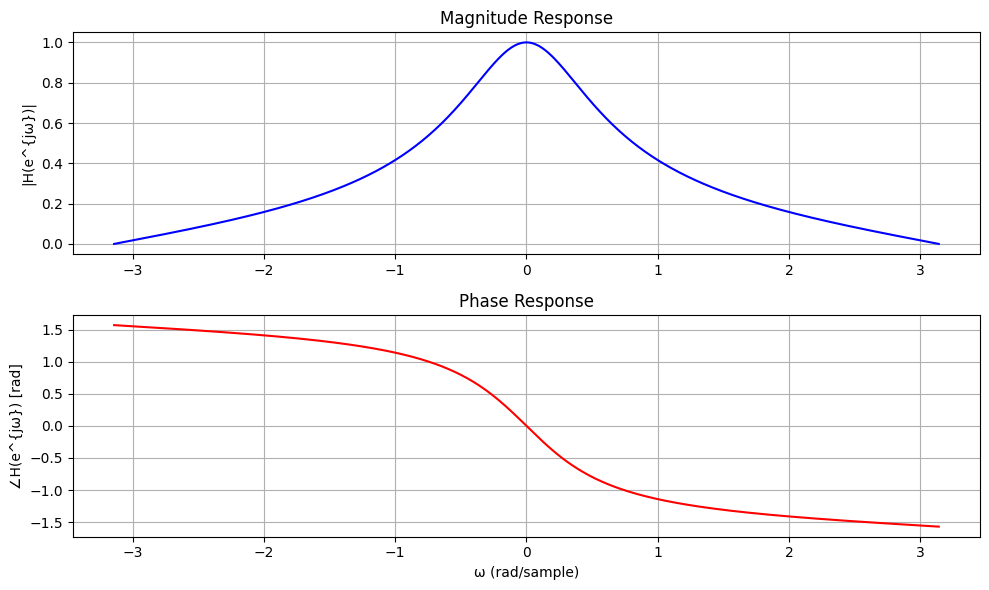

In [146]:
# Paràmetre del filtre
G = (1 - r) / 2

# Rang freqüència
omega = np.linspace(-np.pi, np.pi, 512)

# Magnitud
numerator_mag = 2 * np.cos(omega / 2)
denominator_mag = np.sqrt(1 + r**2 - 2 * r * np.cos(omega))
H_mag = G * numerator_mag / denominator_mag

# Fase
phase = -omega / 2 - np.arctan2(r * np.sin(omega), 1 - r * np.cos(omega))

# Plot
plt.figure(figsize=(10, 6))

# Magnitud
plt.subplot(2, 1, 1)
plt.plot(omega, H_mag, 'b')
plt.title('Magnitude Response')
plt.ylabel('|H(e^{jω})|')
plt.grid(True)

# Fase
plt.subplot(2, 1, 2)
plt.plot(omega, phase, 'r')
plt.title('Phase Response')
plt.xlabel('ω (rad/sample)')
plt.ylabel('∠H(e^{jω}) [rad]')
plt.grid(True)

plt.tight_layout()
plt.show()


1.4. Change the parameter $r$ in the range $(0, 1)$. What happens when $r$ is increased?

A mesura que 𝑟 augmenta, el filtre es torna més “resonant”, amb una resposta impulsional més llarga i una resposta en freqüència més concentrada a baixes freqüències. És a dir, contra més alt és r, el filtre passa menys freqüències altes.

1.5 What type of filter is (low-pass, band-pass, or high-pass filter)?


Tal com es pot observar en el gràfic de la magnitud segons la freqüència, és un filtre 'passa-baixes', ja que el pic de la magnitud es troba sempre a w=0 i els zeros a w=+π i w=-π, independentment del valor de r.

1.6 Now we can use this IIR filter to extract the envelope. Let's define a new function `envelope_iir(x)` that applies the filter to the absolute value of the signal. Note that we are using signal.lfilter function to apply the filter.


In [147]:
def envelope_iir(x, r=0.995):
    x_rectified = np.abs(x)
    b = [1, 1]
    a = [1, -r]
    gain = 2 / (1 - r)
    y = signal.lfilter(b, a, x_rectified) / gain
    return y

Extract the envelope of your reference signal using both the FIR and IIR filters and compare the results plot them along with the signal. Change the value of $r$ until you are comfortable with the result.

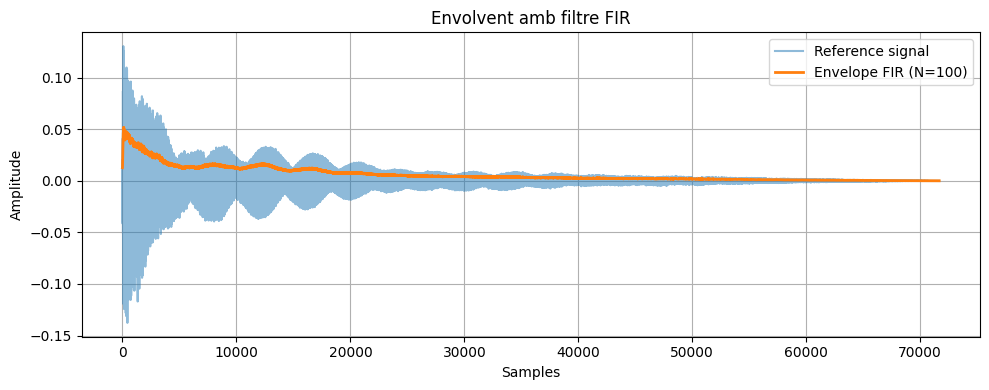

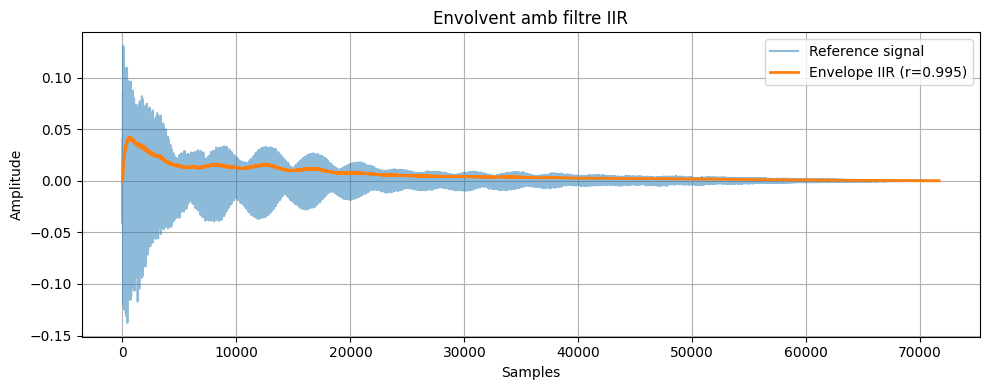

In [148]:
# Representació gràfica

# FIR envelope
env_fir = envelope(reference, N=100)

plt.figure(figsize=(10, 4))
plt.plot(reference, label="Reference signal", alpha=0.5)
plt.plot(env_fir, label="Envelope FIR (N=100)", linewidth=2)
plt.title("Envolvent amb filtre FIR")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# IIR envelope
env_iir = envelope_iir(reference, r=0.995)

plt.figure(figsize=(10, 4))
plt.plot(reference, label="Reference signal", alpha=0.5)
plt.plot(env_iir, label="Envelope IIR (r=0.995)", linewidth=2)
plt.title("Envolvent amb filtre IIR")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1.7 What are the main differences between the two filters? For instance, compare the number of coefficients.

Els filtres FIR i IIR tenen diferències fonamentals tant en estructura com en comportament. El filtre FIR amb 𝑁=100 utilitza 100 coeficients al numerador i cap al denominador, cosa que el fa estable i predictible, amb una resposta impulsional finita. En canvi, el filtre IIR amb 𝑟=0.95 només té dos coeficients (numerador: [1, 1], denominador: [1, −0.995]), però la seva resposta impulsional és infinita i decau exponencialment, cosa que li dona memòria.

A nivell pràctic, el FIR ofereix una envolvent més suau i controlada, però amb més retard i cost computacional. L’IIR, en canvi, és més eficient i segueix millor els canvis ràpids del senyal, tot i que pot amplificar més si no es compensa el guany. Amb els valors que has escollit, ambdós filtres funcionen bé: el FIR suavitza amb estabilitat, i l’IIR respon amb agilitat mantenint una bona forma d’envolvent.

1.8 Apply the new envelope (extracted from the IIR filter) to the synthesis generated with the `synthesize` function and listen to the result.

In [149]:
# Apliquem l’envolvent al senyal sintetitzat
synth *= env_iir

# Normalització del senyal
synth = A_ref * synth / np.max(np.abs(synth))

# Escoltem el resultat
ipd.Audio(synth, rate=fs)

---

**2. Band-pass filters**

Now let's work with the following system: 

$$
H(z) = \frac{(1-z^{-1})(1+z^{-1})}{(1-re^{j\omega_n}z^{-1})(1-re^{-j\omega_n}z^{-1})}, \quad 0<r<1
$$

Note that the poles are $p_1 = re^{j\omega_n}$ and $p_2 = re^{-j\omega_n}$; and the zeros are $z_1=1$ and $z_2=-1$. 

2.1 Use the function `plot_zeros_poles` to plot the zeros and poles of the system.

Note: use $w_n = \pi/4$ and $r=0.99$.

In [150]:
r = 0.99
Wn = np.pi / 4

# Zeros en z = 1 i z = -1
z = [1, -1]

# Pols conjugats en el cercle de radi r
p = [r * np.exp(1j * Wn), r * np.exp(-1j * Wn)]

# Representació
plot_zeros_poles(z, p)


2.2 Show analytically that $a_k = [1, -2rcos(\omega_n), r^2]$ and $b_k=[1, 0, -1]$.

Començant des de la funció de transferència H(Z):

$$
H(z) = \frac{(1-z^{-1})(1+z^{-1})}{(1-re^{j\omega_n}z^{-1})(1-re^{-j\omega_n}z^{-1})}, \quad 0<r<1
$$

Expandim el numerador:

$$
(1 - z^{-1})(1 + z^{-1}) = 1 - z^{-2}
$$

Aquest polinomi pel numerador correspon als coeficients:

$$
B_k = [1,\ 0,\ -1]
$$

Pel denominador, multipliquem els conjugats complexes:

$$
(1 - re^{j\omega_n}z^{-1})(1 - re^{-j\omega_n}z^{-1})
= 1 - r(e^{j\omega_n} + e^{-j\omega_n})z^{-1} + r^2 z^{-2}
$$

Com que $e^{j\omega_n} + e^{-j\omega_n} = 2\cos(\omega_n)$, tenim que:
$$
1 - 2r\cos(\omega_n)\,z^{-1} + r^2 z^{-2}
$$

Per tant, els coeficients del denominador són:

$$
A_k = [1,\ -2r\cos(\omega_n),\ r^2]
$$


2.3 Plot the frequency response of the filter. Confirm this is a band-pass filter. What's the central frequency of the passband?

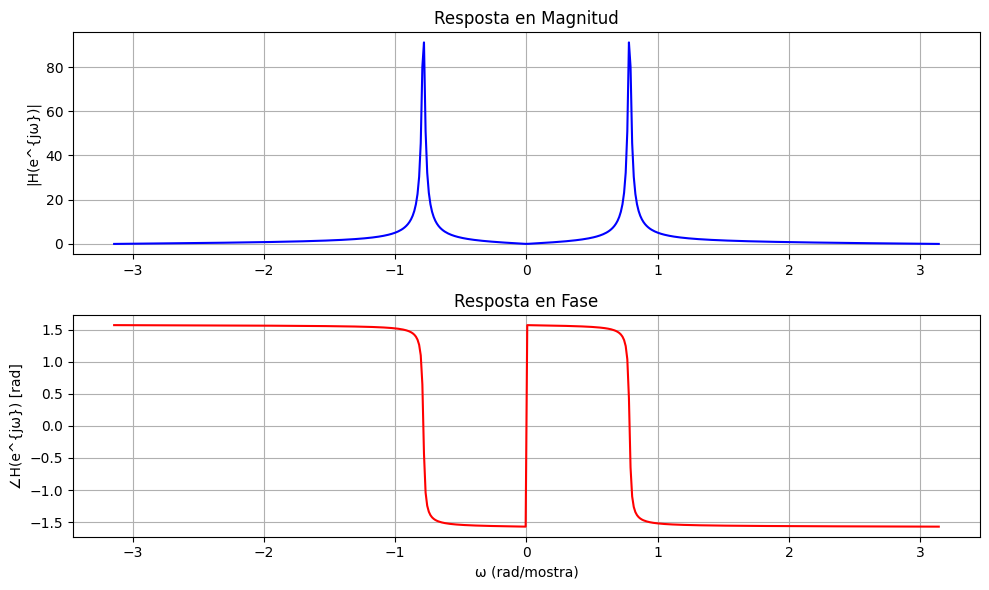

In [151]:
# Rang freqüència
omega = np.linspace(-np.pi, np.pi, 512)

# Magnitud del numerador
numerator_mag = np.abs((1 - np.exp(-1j * omega)) * (1 + np.exp(-1j * omega)))

# Magnitud del denominador
denominator_mag = np.abs((1 - r * np.exp(1j * Wn) * np.exp(-1j * omega)) *
                         (1 - r * np.exp(-1j * Wn) * np.exp(-1j * omega)))

# Resposta en magnitud
H_mag = numerator_mag / denominator_mag

# Resposta en fase
H_phase = np.angle((1 - np.exp(-1j * omega)) * (1 + np.exp(-1j * omega)) /
                   ((1 - r * np.exp(1j * Wn) * np.exp(-1j * omega)) *
                    (1 - r * np.exp(-1j * Wn) * np.exp(-1j * omega))))

# Gràfics
plt.figure(figsize=(10, 6))

# Magnitud
plt.subplot(2, 1, 1)
plt.plot(omega, H_mag, 'b')
plt.title('Resposta en Magnitud')
plt.ylabel('|H(e^{jω})|')
plt.grid(True)

# Fase
plt.subplot(2, 1, 2)
plt.plot(omega, H_phase, 'r')
plt.title('Resposta en Fase')
plt.xlabel('ω (rad/mostra)')
plt.ylabel('∠H(e^{jω}) [rad]')
plt.grid(True)

plt.tight_layout()
plt.show()



Observant el gràfic de la resposta en magnitud es confirma que el filtre és 'passa-bandes'. A més, la freqüència central del filtre és $\pi/4$, que és igual a $w_n$. En el gràfic es pot veure com la majoria de freqüències tenen magnitud propera a 0 excepte per les freqüències properes a $\pi/4$ o $-\pi/4$.


2.4 Define a function `bpf(x, f, r, fs)` that applies the above band-pass filter. 

Note 1: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$.

Note 2: use `signal.lfilter` function to implement the filter.

In [152]:
def bpf(x, fn, fs, r=0.995):
    """Applies a band-pass filter with central frequency fn

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    fn: int or float
        Central frequency of the band pass in Hz 
    fs : int or float
        Frequency rate in Hz
    r: float
        Magnitude of the poles

    Returns
    -------
    y : np.array
        The output of the filter
    """
    # Freqüència normalitzada en radians/mostra
    Wn = 2 * np.pi * fn / fs

    # Coeficients del numerador (zeros en z=1 i z=-1)
    b = np.convolve([1, -1], [1, 1])  # = [1, 0, -1]

    # Coeficients del denominador (pols conjugats en re^{±jWn})
    a = [1, -2 * r * np.cos(Wn), r**2]

    # Aplicació del filtre
    y = signal.lfilter(b, a, x)

    return y


2.5 Regardless of the phase, until now we were synthesizing the instrument signal by summing $K$ harmonics of the signal with different weights ($A_k$) and multiplying the sum by the envelope of the reference signal ($e(t)$):

$$y(t) = e(t) \cdot \sum_{k=1}^K A_k\cos\left(2\pi kf_0 t \right), $$

where $f_0$ is the fundamental frequency of the note. Now we want to improve this synthesis by finding a time-dependent amplitude ($A_k(t)$) for each harmonic:

$$y(t) = \sum_{k=1}^K A_k(t) \cos\left(2\pi kf_0 t \right), $$

where $A_k(t)$ is the amplitude of the harmonic $k$. To extract the amplitudes $A_k(t)$ we'll apply a band-pass filter with central frequency $kf_0$ and calculate the envelope of the output by using the `envelope_iir`.


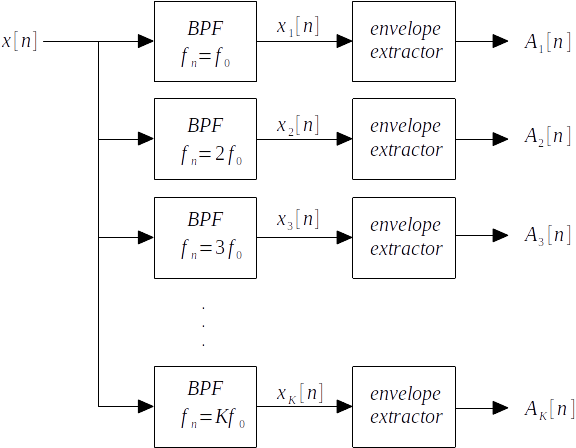

For instance, the following code should extract the envelope of the fundamental frequency component. Change the value of $f_0$ to coincide with your fundamental frequency and check the result. 

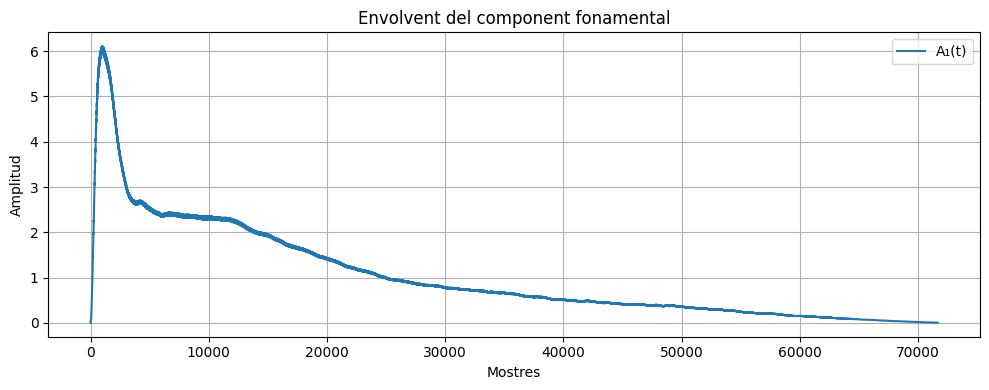

In [153]:
# Paràmetres
f0 = 915.16       # Freqüència fonamental (Hz)
fs = 44100        # Freqüència de mostreig
r = 0.995         # Factor de pols del filtre

# Filtratge passa-banda centrat a f0
x1 = bpf(reference, f0, fs, r=r)

# Extracció de l’envolvent del component fonamental
A1_t = envelope_iir(x1, r=r)

# Visualització (opcional)
plt.figure(figsize=(10, 4))
plt.plot(A1_t, label='A₁(t)')
plt.title('Envolvent del component fonamental')
plt.xlabel('Mostres')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


2.6 Complete the `synthetize_with_bpf` function to implement a synthesis applying different envelopes for each harmonic.


In [154]:
def synthetize_with_bpf(x, f0, phi, K, fs):
  """Synthetizes an harmonic signal using different envelopes for each harmonic
  The envelops are extracted from the reference signal x.

  Parameters
  ----------
  x : np.array
      The reference signal in the form of a numpy array
  f0: int or float
      Fundamental frequency of the synthesis
  phi : float
      Phase
  K: int
      Number of harmonics
  fs : int or float
      Frequency rate in Hz

  Returns
  -------
  y : np.array
      The output of the filter

  """

  t = np.arange(len(x))/fs
  y = np.zeros_like(x, dtype=float)

  # Per cada harmònic
  for k in range(1, K + 1):
    fk = k * f0
    # Filtratge passa-banda
    r_k = np.clip(0.995 - 0.002*(k-1), 0.96, 0.999)
    xk = bpf(x, fk, fs, r_k)

    # Extracció de l’envolvent
    Ak_t = envelope_iir(xk, r=r)
    # Suma de la síntesi
    y += Ak_t * np.cos(2 * np.pi * fk * t + k * phi - (k-1)*np.pi/2)

  # Normalització
  y /= np.max(np.abs(y))
  return y

2.6 Call the function `synthetize_with_bpf` to get the synthesized signal and **listen to it**.

Note that now you can increase the number of harmonics $K$ as you want because we are not manually measuring the weights of each harmonic.

In [155]:
# Carreguem el senyal de referència
reference, fs = load_audio('audio/reference.wav')

# Paràmetres de síntesi
f0 = 915.16        # freqüència fonamental
phi = -np.pi/2     # fase inicial
K = 35             # nombre d’harmònics 
r = 0.995          # factor de pols

# Crida a la funció de síntesi amb BPF
synth = synthetize_with_bpf(reference, f0, phi, K, fs)

# Escoltar el resultat
ipd.Audio(synth, rate=fs)


2.7 Compare the **spectrograms** of the synthesized signal and reference signal.

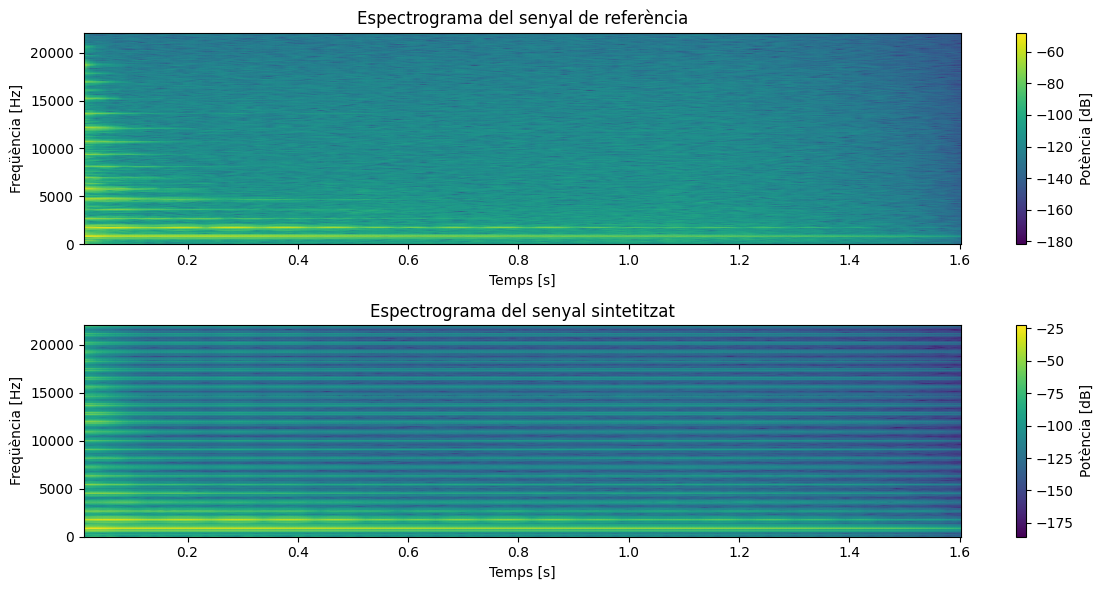

In [156]:
from scipy.signal import spectrogram

# Espectrograma del senyal de referència
f_ref, t_ref, Sxx_ref = spectrogram(reference, fs=fs, nperseg=1024, noverlap=512)
# Espectrograma del senyal sintetitzat
f_syn, t_syn, Sxx_syn = spectrogram(synth, fs=fs, nperseg=1024, noverlap=512)

plt.figure(figsize=(12, 6))

# Espectrograma referència
plt.subplot(2, 1, 1)
plt.pcolormesh(t_ref, f_ref, 10*np.log10(Sxx_ref), shading='gouraud')
plt.title('Espectrograma del senyal de referència')
plt.ylabel('Freqüència [Hz]')
plt.xlabel('Temps [s]')
plt.colorbar(label='Potència [dB]')

# Espectrograma síntesi
plt.subplot(2, 1, 2)
plt.pcolormesh(t_syn, f_syn, 10*np.log10(Sxx_syn), shading='gouraud')
plt.title('Espectrograma del senyal sintetitzat')
plt.ylabel('Freqüència [Hz]')
plt.xlabel('Temps [s]')
plt.colorbar(label='Potència [dB]')

plt.tight_layout()
plt.show()
